# TP Graph Edit Distance

## 1) GED problem visualisation :

First we have a toy problem of two graphs as follows :

In [ ]:
from GED_lib import (graph_loader,path_Dijkstra,
                     draw_pair_graph,make_pair_tree,
                     draw_tree,draw_path,from_leaf_to_path)
import networkx as nx
%matplotlib inline
import numpy as np
import heapq
import itertools

In [2]:
g1_toy = nx.Graph()
g1_toy.add_node(0,node_label = "O")
g1_toy.add_node(1,node_label = "C")
g1_toy.add_node(2,node_label = "O")
g1_toy.add_node(3,node_label = "N")
g1_toy.add_edge(0,1,edge_label = 1)
g1_toy.add_edge(1,2,edge_label = 1)
g1_toy.add_edge(2,3,edge_label = 1)
g1_toy.add_edge(3,1,edge_label = 1)

g2_toy = nx.Graph()
g2_toy.add_node(0,node_label = "N")
g2_toy.add_node(1,node_label = "C")
g2_toy.add_node(2,node_label = "C")
g2_toy.add_edge(0,1,edge_label = 1)
g2_toy.add_edge(1,2,edge_label = 1)

(<AxesSubplot: >, <AxesSubplot: >)

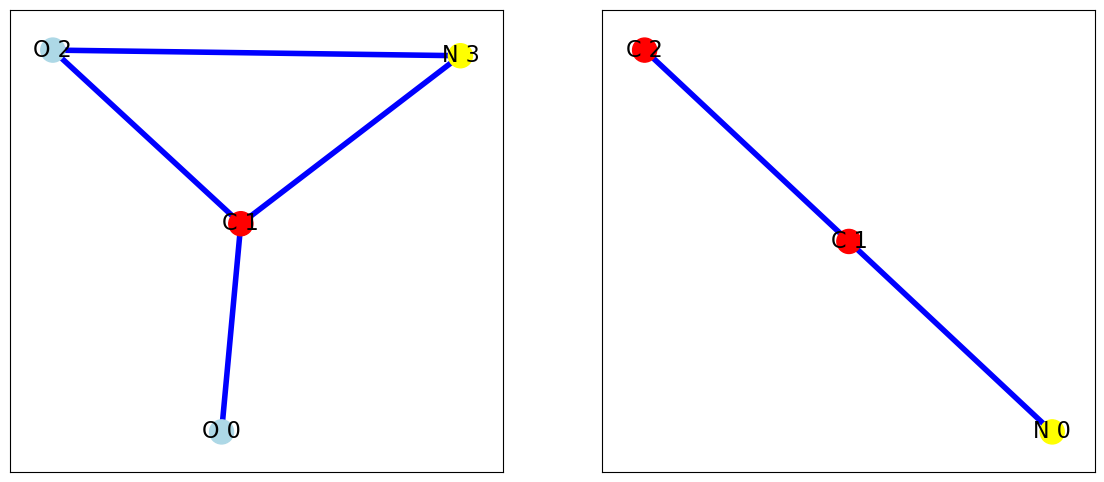

In [3]:
draw_pair_graph(g1_toy,g2_toy)

We want to compute the graph edit distance(GED) between the two graphs above.

The first simple idea to do this is to compute the tree representing the GED problem with all possible matches.

Then find a shortest path in this tree to find an optimal match corresponding to the GED value.

To compute the GED, we have 2 sets of edit operation costs defined as follows:

In [4]:
cost1 = {'n_ins':4,'n_sub':2,'n_del':4,'e_ins':1,'e_sub':1,'e_del':1}
cost2 = {'n_ins':4,'n_sub':2,'n_del':4,'e_ins':2,'e_sub':1,'e_del':2}

We can now calculate the tree, here with the cost1:

In [5]:
tree = make_pair_tree(g1_toy,g2_toy,cost1)

<AxesSubplot: >

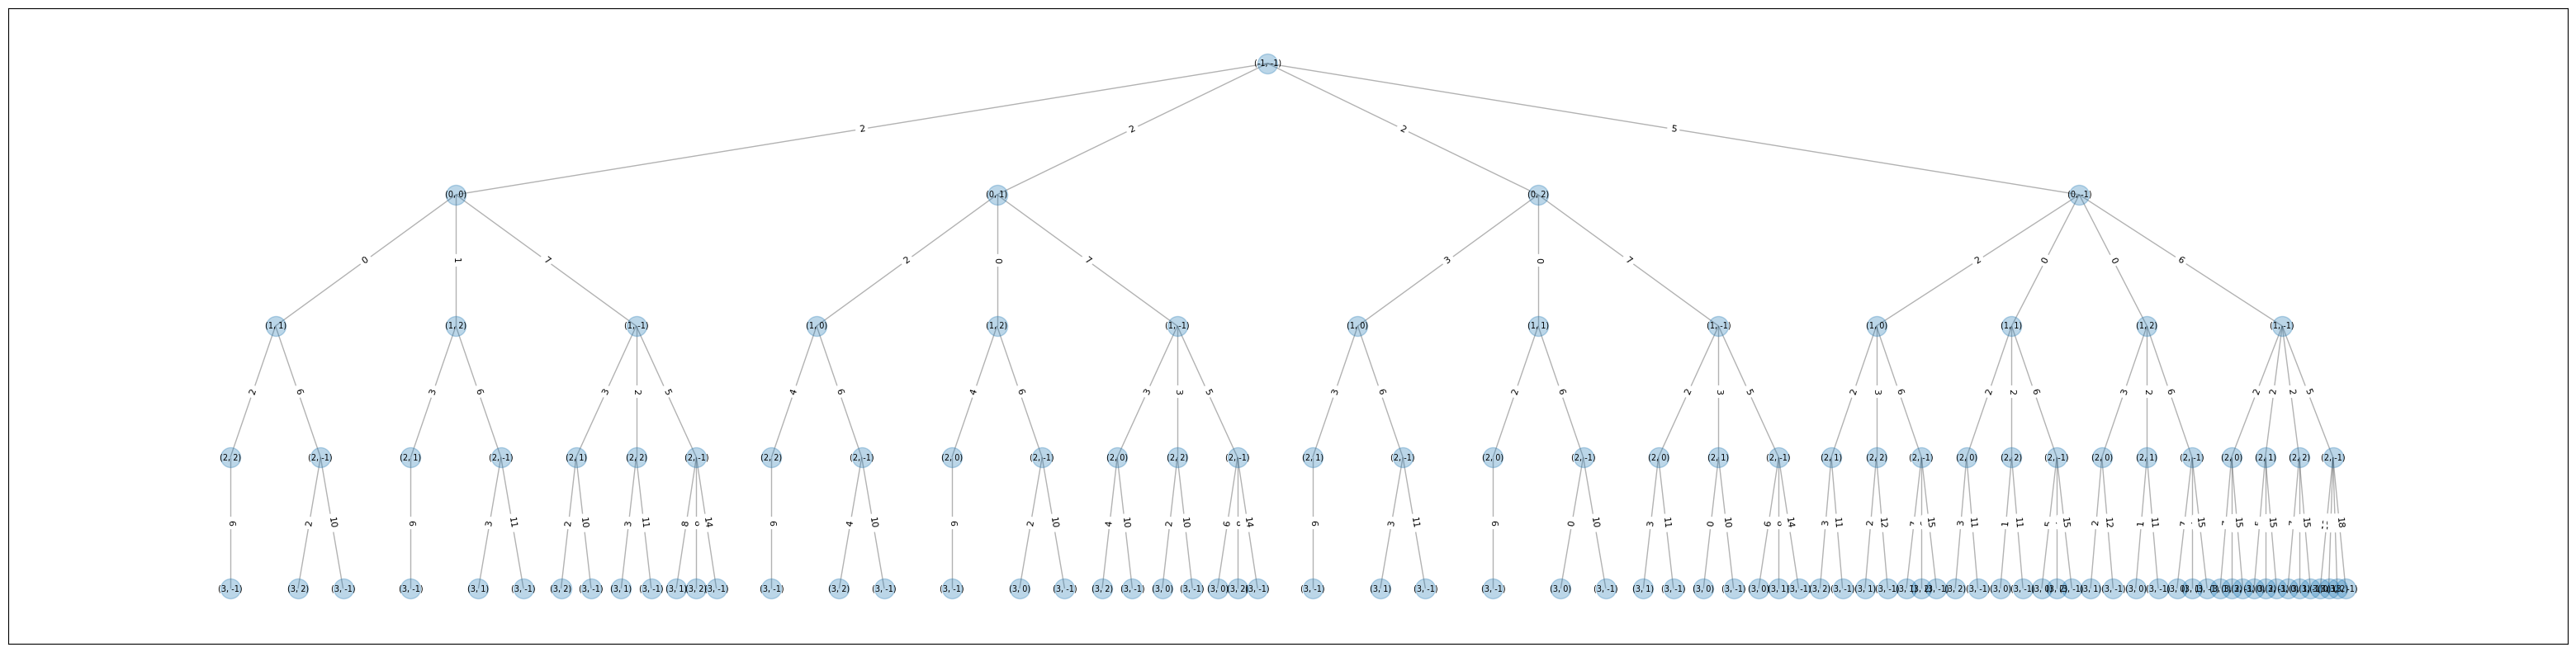

In [6]:
draw_tree(tree)

The tree above represents all possible paths to transform g1_toy into g2_toy.

We can now compute a shortest path and the cost of this path correspond to the GED value. (-1) values in a path represent either insertion or deletion.
An exemple of path : [(0,1),(-1,0),(2,-1),(3,2),(1,-1)], where the matching (i,j) is a substitution of node i whith the node j, (i,-1) a deletion of node i in the first graph and (-1,j) an insertion of node j in the second graph.
A substitution of same element have always a cost of 0 associated.

In [7]:
ged,path = path_Dijkstra(tree,g1_toy,g2_toy)
print("Graph Edit Distance value : ",ged)

Graph Edit Distance value :  8.0


In [8]:
print(path)

[82, 35, 12, 3, 0]


In [9]:
idx_path = from_leaf_to_path(tree,path,g1_toy,g2_toy)
print("The node matching between graphs : ",idx_path)

The node matching between graphs :  [(0, 2), (1, 1), (2, -1), (3, 0)]


We get a node matching between the two graphs, which corresponds to a shortest path in the tree, all edges matching can be deduced from the node matching.

<AxesSubplot: >

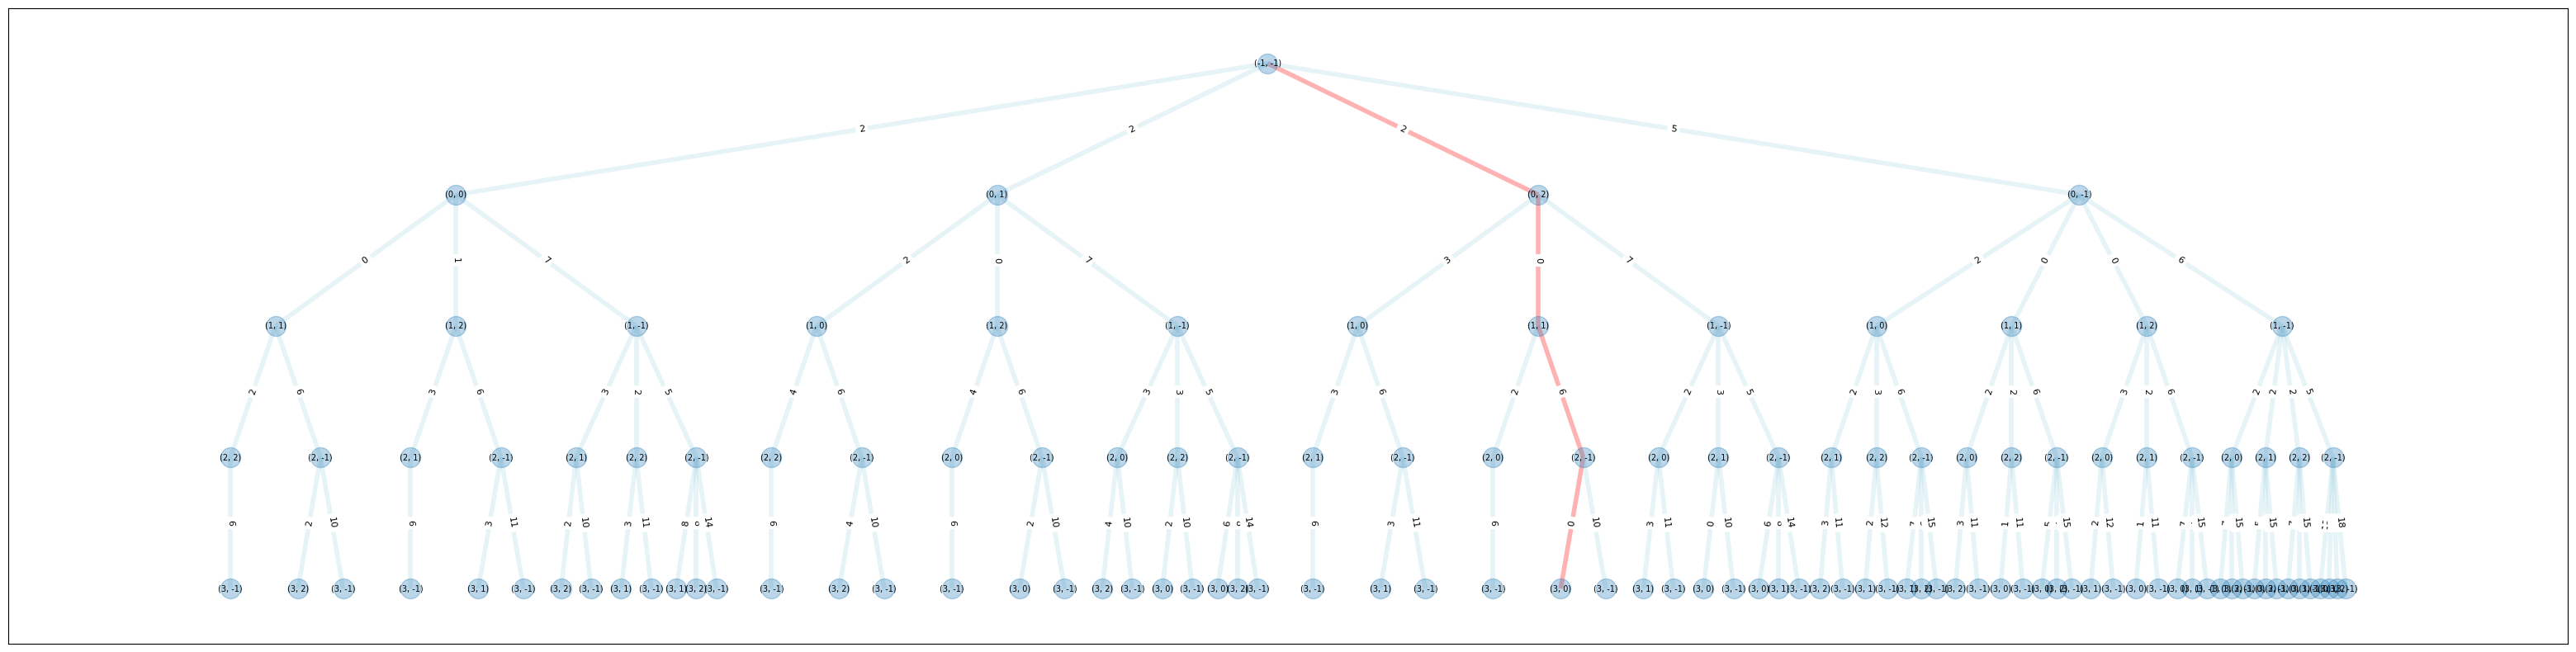

In [10]:
draw_path(tree,path)

One of the edit path that minimise the GED value is colored in red in the tree.

### Question 1) :
What are the drawbacks of this technique? and why it is not used in practise?

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The calculation grows exponentially with time, that means that it is not efficient for larger graphs, it limited for graphs under 15 nodes. 
  </p>
</div>

## 2) Astar GED :

Download the "data" file on universitice then extract its path. This file contains six graphs of chemical compounds with different atoms (nitrogen, oxygen and carbon) and different types of bonds (single, double or triple bond).

In [11]:
path = "./data"

In [12]:
data = graph_loader(path)
data

{'g0': <networkx.classes.graph.Graph at 0x7eaff3caa330>,
 'g1': <networkx.classes.graph.Graph at 0x7eaff3c45a60>,
 'g2': <networkx.classes.graph.Graph at 0x7eaff3c47410>,
 'g3': <networkx.classes.graph.Graph at 0x7eafea9e0920>,
 'g4': <networkx.classes.graph.Graph at 0x7eafea9e3da0>,
 'g5': <networkx.classes.graph.Graph at 0x7eafea9e17f0>}

You can use the draw_pair_graph() function to visualize graphs

(<AxesSubplot: >, <AxesSubplot: >)

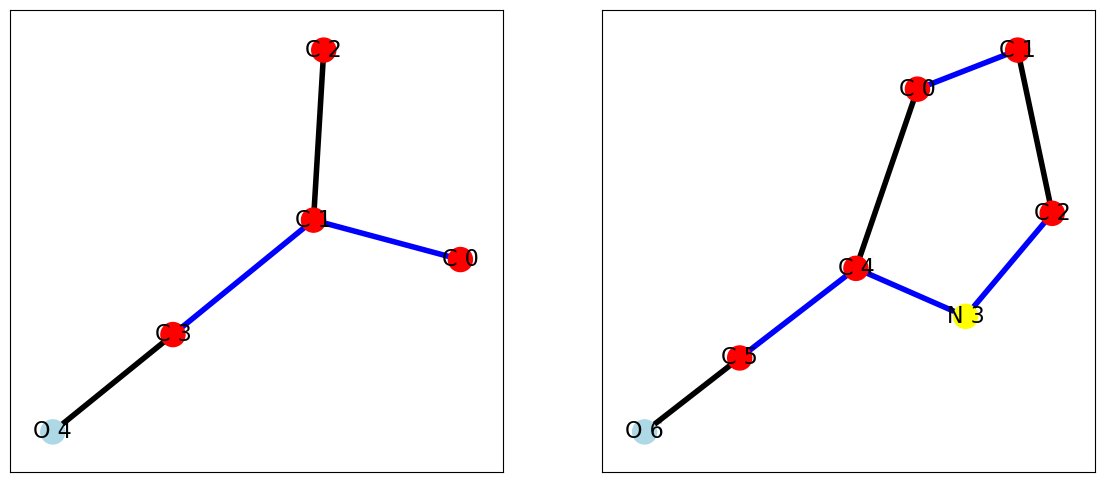

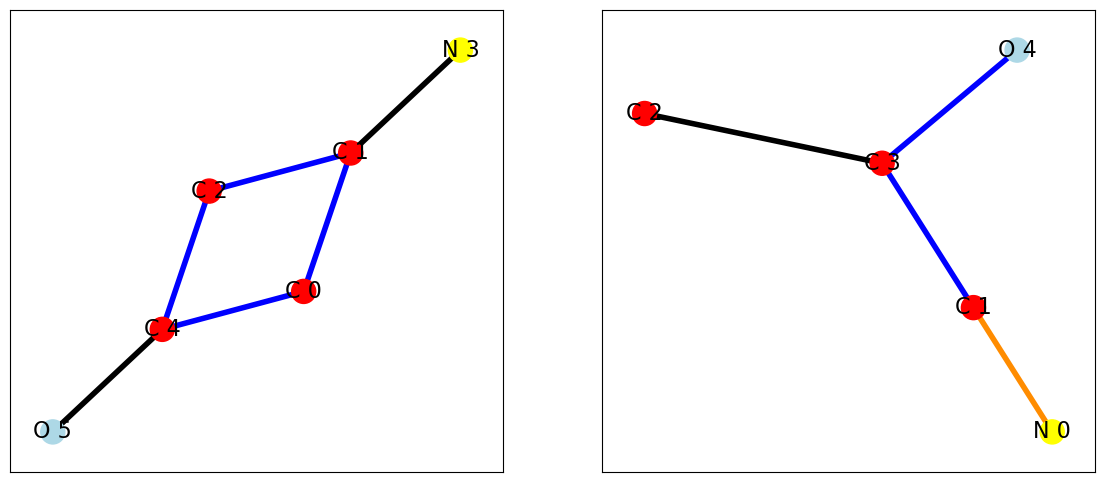

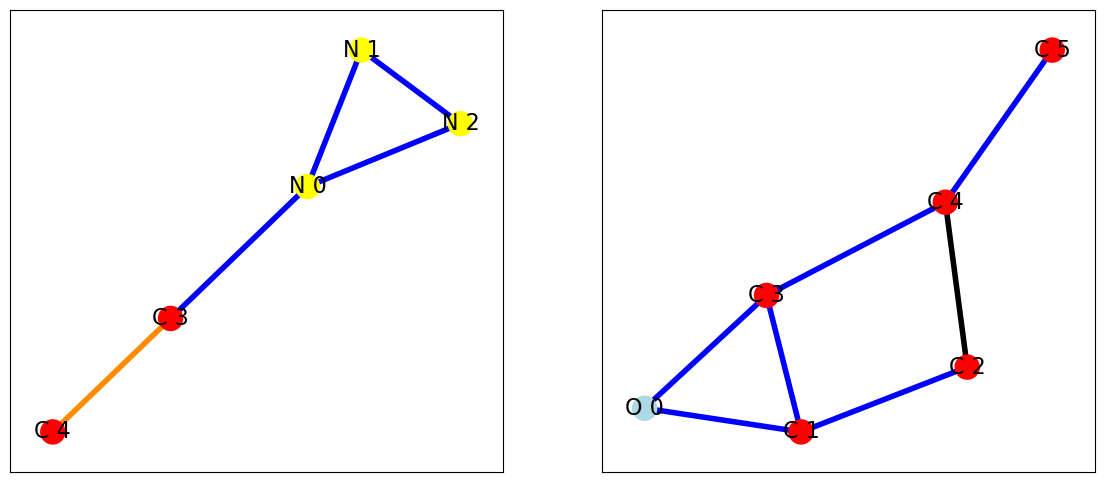

In [13]:
draw_pair_graph(data["g0"],data["g1"])
draw_pair_graph(data["g2"],data["g3"])
draw_pair_graph(data["g4"],data["g5"])

### Question 2):



First define a cost function that will compute the cost of a path. Taking account insertion, deletion and substitution of nodes and edges.

In [14]:
def cost_path(g1, g2, path, cost):
    node_cost = 0
    edge_cost = 0

    mapping = {}  # g1_node -> g2_node
    for n1, n2 in path:
        if n1 is None:
            node_cost += cost['n_ins']
        elif n2 is None:
            node_cost += cost['n_del']
        else:
            node_cost += cost['n_sub'] if g1.nodes[n1] != g2.nodes[n2] else 0
            mapping[n1] = n2

    # Handle edges
    for (u1, v1) in g1.edges:
        if u1 in mapping and v1 in mapping:
            u2, v2 = mapping[u1], mapping[v1]
            if g2.has_edge(u2, v2):
                edge_cost += cost['e_sub'] if g1.edges[u1, v1] != g2.edges[u2, v2] else 0
            else:
                edge_cost += cost['e_del']
        elif u1 in mapping or v1 in mapping:
            edge_cost += cost['e_del']

    for (u2, v2) in g2.edges:
        g1_u = [k for k, v in mapping.items() if v == u2]
        g1_v = [k for k, v in mapping.items() if v == v2]
        if not g1_u or not g1_v or not g1.has_edge(g1_u[0], g1_v[0]):
            edge_cost += cost['e_ins']

    return node_cost + edge_cost


We also need a function that verify if a path is complete or not.

In [15]:
def is_complete(g1, g2, path):
    g1_nodes = set(g1.nodes)
    g2_nodes = set(g2.nodes)

    mapped_g1 = set()
    mapped_g2 = set()

    for n1, n2 in path:
        if n1 is not None:
            mapped_g1.add(n1)
        if n2 is not None:
            mapped_g2.add(n2)

    return mapped_g1 == g1_nodes and mapped_g2 == g2_nodes


Eventually the A* core function.

In [ ]:
def A_star(g1, g2, cost):
    g1_nodes = list(g1.nodes)
    g2_nodes = list(g2.nodes)

    initial_path = []
    open_set = []
    counter = itertools.count()  # tie-breaker

    heapq.heappush(open_set, (0, next(counter), initial_path))

    best_path = None
    best_cost = float('inf')

    while open_set:
        curr_cost, _, path = heapq.heappop(open_set)

        if is_complete(g1, g2, path):
            if curr_cost < best_cost:
                best_cost = curr_cost
                best_path = path
            continue

        # Get unmapped nodes
        mapped_g1 = {n1 for n1, _ in path if n1 is not None}
        mapped_g2 = {n2 for _, n2 in path if n2 is not None}

        unmapped_g1 = [n for n in g1_nodes if n not in mapped_g1]
        unmapped_g2 = [n for n in g2_nodes if n not in mapped_g2]

        # Generate successors
        if unmapped_g1 and unmapped_g2:
            n1 = unmapped_g1[0]
            for n2 in unmapped_g2:
                new_path = path + [(n1, n2)]
                total_cost = cost_path(g1, g2, new_path, cost)
                heapq.heappush(open_set, (total_cost, next(counter), new_path))

        if unmapped_g1:
            n1 = unmapped_g1[0]
            new_path = path + [(n1, None)]
            total_cost = cost_path(g1, g2, new_path, cost)
            heapq.heappush(open_set, (total_cost, next(counter), new_path))

        if unmapped_g2:
            n2 = unmapped_g2[0]
            new_path = path + [(None, n2)]
            total_cost = cost_path(g1, g2, new_path, cost)
            heapq.heappush(open_set, (total_cost, next(counter), new_path))

    return best_cost, best_path


In [18]:
graphs = [data["g0"], data["g1"], data["g2"], data["g3"], data["g4"], data["g5"]]

results = []

for i in range(len(graphs)):
    for j in range(i + 1, len(graphs)):
        ged, path = A_star(graphs[i], graphs[j], cost1)
        results.append([i, j, ged])


In [19]:
headers = ["Graph 1", "Graph 2", "GED_cost1"]

def format_row(row):
    return " | ".join(f"{str(item).rjust(7)}" for i, item in enumerate(row))

print(format_row(headers))
print("-" * (31))  

for row in results:
    print(format_row(row))

Graph 1 | Graph 2 | GED_cost1
-------------------------------
      0 |       1 |      13
      0 |       2 |       8
      0 |       3 |       5
      0 |       4 |      10
      0 |       5 |       8
      1 |       2 |      10
      1 |       3 |      14
      1 |       4 |      17
      1 |       5 |      11
      2 |       3 |      10
      2 |       4 |      13
      2 |       5 |       6
      3 |       4 |       9
      3 |       5 |      11
      4 |       5 |      13


Check your A* function and your cost function for the toy problem and the six graphs for cost1 using the table with GED values above.

|Graph1| 	Graph2| 	GED_cost1|
| :--------------- |:---------------:| -----:|
| 	0|	1|	13.0|
| 	0| 	2| 	8.0|
| 	0| 	3| 	5.0|
| 	0| 	4| 	10.0|
| 	0| 	5| 	8.0|
| 	1| 	2| 	10.0|
|	1|	3| 	15.0|
|  1| 	4| 	17.0|
| 	1| 	5| 	11.0|
| 	2| 	3| 	10.0|
| 2| 	4| 	13.0|
| 2| 	5| 	6.0|
| 3| 	4| 	9.0|
| 3| 	5| 	11.0|
| 4| 	5| 	13.0|